# Байесовский подход в анализе данных
## Задание 1

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Выполненную работу нужно отправить телеграм-боту. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания получат штраф.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.


**Правила оформления теоретических задач:**

* Решения необходимо прислать одним из следующих способов:
  * фотографией в правильной ориентации, где все четко видно, а почерк разборчив,
    * отправив её как файл боту вместе с ноутбуком *или*
    * вставив её в ноутбук посредством `Edit -> Insert Image` (<font color="red">фото, вставленные ссылкой, не принимаются</font>);
  * в виде $LaTeX$ в markdown-ячейках.
* Решения не проверяются, если какое-то требование не выполнено. Особенно внимательно все проверьте в случае выбора второго пункта (вставки фото в ноутбук). <font color="red"><b>Неправильно вставленные фотографии могут не передаться при отправке.</b></font> Для проверки попробуйте переместить `ipynb` в другую папку и открыть его там.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.

**Баллы за задание:**

* Задача 1 &mdash;  20 баллов
* Задача 2 &mdash;  50 баллов
* Задача 3 &mdash;  70 баллов

In [1]:
# Bot check

# HW_ID: ds_bayes1
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [2]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import scipy.special as sp
from tqdm.auto import tqdm
from scipy.optimize import minimize
import itertools
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import ARDRegression
from sklearn.linear_model import BayesianRidge, Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from collections import defaultdict

plt.rcParams.update({
    "axes.facecolor": "#f0f0f0",
    "figure.facecolor": "#e5e5e5",
    "grid.color": "white",
    "grid.linestyle": "-",         
    "grid.alpha": 0.7,
    "axes.edgecolor": "gray",
    "axes.grid": True
})

__________________
### Задача 1.

Рассмотрим следующую схему

* параметр $\theta \sim \mathcal{N}(a, 1),$

* одно наблюдение $X | \theta \sim \mathcal{N}(b\theta + c, 1),$

где $a, b, c \in \mathbb{R}$ &mdash; гиперпараметры, определяющие разные модели.

Будем рассматривать три модели, определяемые следующими гиперпараметрами:

In [3]:
a = np.array([4, 9, 17])
b = np.array([1, 0, -1])
c = np.array([5, 8, 20])

Зафиксируйте также цвета для каждой из моделей:

In [4]:
cmaps = ["Reds", "Greens", "Blues"]        # для 2D-графиков
colors = ["red", "green", "blue"]  # для 1D-графиков

Для каждой модели сгенерируйте 300 её реализаций и изобразите их на одном графике, в котором значение параметра откладывается по горизонтальной оси, а значение наблюдения &mdash; по вертикальной. Размер и прозрачность точек подберите из соображений наглядности.

Охарактеризуйте, какие данные может достаточно хорошо описать каждая из моделей. Не забудьте, что данные это $X$, а не $\theta$.

In [5]:
N_SAMPLES = 300
realizations = defaultdict(lambda: defaultdict(list))

for i in range(len(a)):
    theta = sps.norm(loc=a[i], scale=1).rvs(size=N_SAMPLES)
    X = sps.norm(loc=b[i] * theta + c[i], scale=1).rvs()
    realizations[i]["observations"]=X
    realizations[i]["theta"]=theta

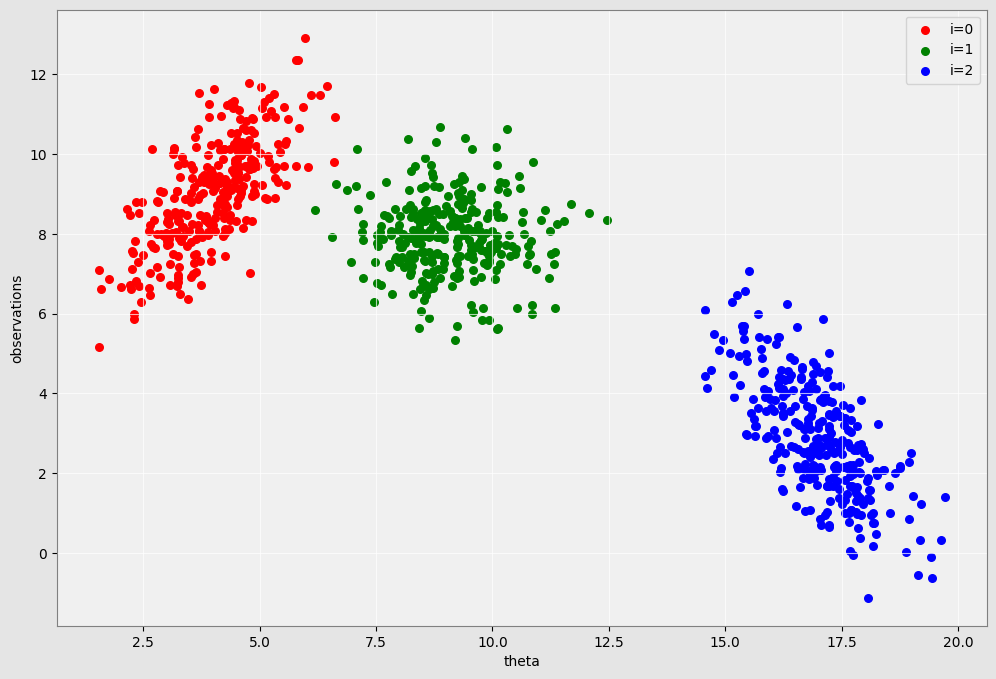

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(len(a)):
    plt.scatter(
        realizations[i]["theta"],
        realizations[i]["observations"],
        color=colors[i],
        s=30,
        label=f"i={i}"
    )

plt.xlabel("theta")
plt.ylabel("observations")
plt.legend()

Первая модель, демонстрирует случай, когда наблюдения линейно зависят от параметра, причем коэффициент наклона больше нуля.

То же самое можно сказать про 3-ю модель, у нее коэффициент наклона меньше нуля.

Данные второй моедели не имеют зависимости от парметра, а просто флуктуируют около константы.

Найдите совместное распределение вектора $(\theta, X)$ и визуализируйте его плотность с помощью линий уровня.

Допустим, мы получили данные $X=8$. Визуализируйте их на графике с помощью горизонтальной линии. Какая из трех моделей лучше всего описывает данные судя по графику?

$p(\theta, X) = \frac{1}{\sqrt{2\pi}} \cdot \exp(-\frac{(\theta - a)^2}{2}) \cdot \frac{1}{\sqrt{2\pi}}\cdot \exp(-\frac{(X - b \theta - c)^2}{2})$


In [7]:
X_grid = np.linspace(-2, 15, num=1000)
theta_grid = np.linspace(1, 22, num=1000)

def get_density(a, b, c, X_grid, theta_grid):
    Theta, X = np.meshgrid(theta_grid, X_grid)
    p_theta = sps.norm(loc=a, scale=1).pdf(Theta)
    p_X_by_theta = sps.norm(loc=b * Theta + c, scale=1).pdf(X)
    return p_theta * p_X_by_theta, Theta, X

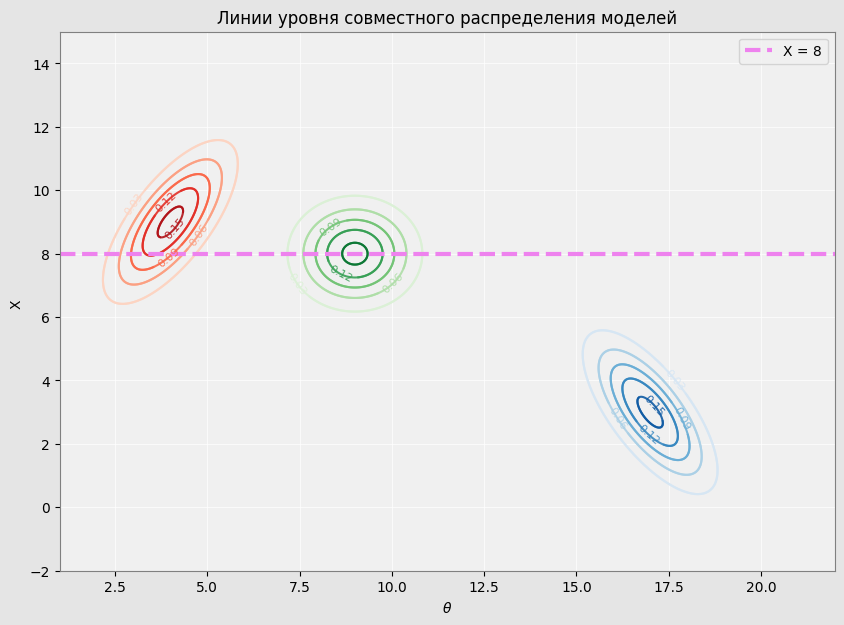

In [8]:
example_X = 8

plt.figure(figsize=(10, 7))

for i, (ai, bi, ci, cmap_i) in enumerate(zip(a, b, c, cmaps)):
    density, Theta, X = get_density(ai, bi, ci, X_grid, theta_grid)
    plt.contour(Theta, X, density, levels=5, cmap=cmap_i, alpha=0.9,)
    cs = plt.contour(Theta, X, density, levels=5, cmap=cmap_i, alpha=0.9)
    plt.clabel(cs, inline=True, fontsize=8)
plt.axhline(8, color="violet", linestyle="--", linewidth=3, label=f"X = {example_X}")

plt.xlabel(r"$\theta$")
plt.ylabel("X ")
plt.title("Линии уровня совместного распределения моделей")
plt.grid(True)
plt.legend()
plt.show()

Так как вероятность получить 8 больше у второй модели, то она скорее всего и описывает полученные данные. Также возможно, что данные описывает 1-я модель, вероятность того, что данные описывает вторая модель крайне мала.

Укажите апостериорное распределение $\theta$.

На одном графике визуализируйте априорные и апостериорные плотности во всех трех моделях. Априорные плотности рисуйте пунктирной линией, апостериорные &mdash; более толстой сплошной линией. Не забывайте про цвет моделей.

*Совет.* Для наглядности стоит рисовать плотность только для тех точек, в которых эта плотность не меньше $10^{-3}$.

Мы знаем, что сопряженным априорным распределением для нормального распределения, с известной дисперсией является нормальное. В нашем случае theta действительно имеет сопряженный априор.

Из лекции BS.2 известно, что апостериорное распределение имеет вид:

\begin{align*}
q(\theta \mid x_1, \dots, x_n) &\sim \exp\Big(-\frac{1}{2} (\theta - a)^2 \Big) \cdot \prod_{i=1}^n \exp\Big(-\frac{1}{2} (x_i - b\theta - c)^2 \Big) \\[2mm]
&= \exp\Bigg(-\frac12 \Big( (\theta - a)^2 + \sum_{i=1}^n (x_i - b\theta - c)^2 \Big) \Bigg) \\[1mm]
&= \exp\Bigg(-\frac12 \Big( (1 + n b^2)\theta^2 - 2\big(a + b \sum_{i=1}^n (x_i - c)\big)\theta + a^2 + \sum_{i=1}^n (x_i - c)^2 \Big) \Bigg) \\[1mm]
&\sim \exp\Bigg(-\frac12 (1+n b^2) \Big[ \theta^2 - \frac{2(a + b \sum_{i=1}^n (x_i - c))}{1+n b^2} \theta \Big] \Bigg) \\[1mm]
&\sim \exp\Bigg(-\frac12 (1+n b^2) \Big[ \theta - \frac{a + b \sum_{i=1}^n (x_i - c)}{1+n b^2} \Big]^2 \Bigg)
\end{align*}

В итоге

$$
\boxed{
\theta \mid x_1, \dots, x_n \sim \mathcal{N}\Biggl(
\frac{a + b \sum_{i=1}^n (x_i - c)}{1 + n b^2}, \frac{1}{1 + n b^2}
\Biggr)
}.
$$



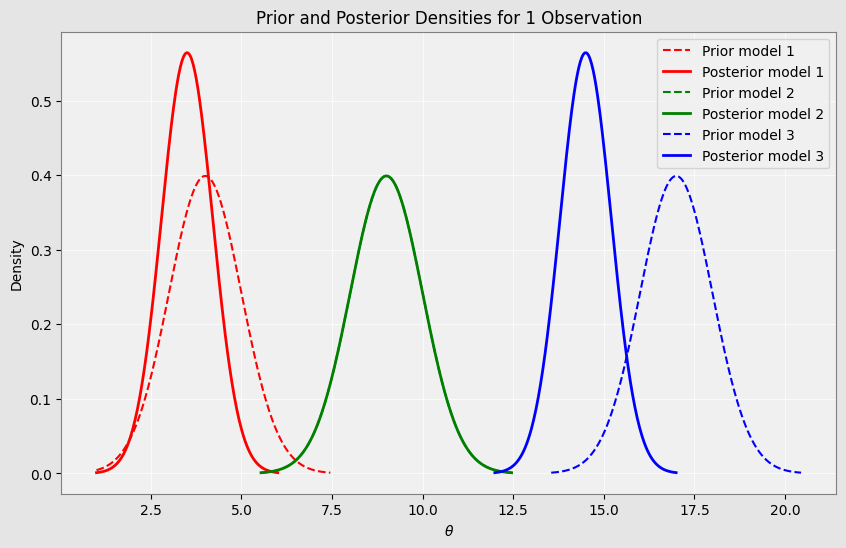

In [9]:
plt.figure(figsize=(10, 6))

for i, (ai, bi, ci, color) in enumerate(zip(a, b, c, colors)):
    prior = sps.norm.pdf(theta_grid, loc=ai, scale=1)
    prior_mask = prior >= 1e-3
    plt.plot(theta_grid[prior_mask], prior[prior_mask], linestyle='--', color=color, label=f'Prior model {i+1}')

    x = 8

    mu_post = (ai + bi * np.sum(x - ci)) / (1 + bi**2)
    sigma_post = 1 / np.sqrt(1 + bi**2)
    post = sps.norm.pdf(theta_grid, loc=mu_post, scale=sigma_post)
    post_mask = post >= 1e-3
    plt.plot(theta_grid[post_mask], post[post_mask], linestyle='-', linewidth=2, color=color, label=f'Posterior model {i+1}')

plt.xlabel(r'$\theta$')
plt.ylabel('Density')
plt.title(f'Prior and Posterior Densities for {1} Observation')
plt.grid(True)
plt.legend()
plt.show()


Визуализируйте на одном графике маргинальную плотность наблюдения $X$ для каждой из трех моделей. Отметьте точкой значение плотности для $X=8$, это будет обоснованной (evidence) каждой из моделей. 

Маргинальное распределние имеет вид 
$$
X \sim \mathcal{N}(ba + c, 1 + b^2)
$$

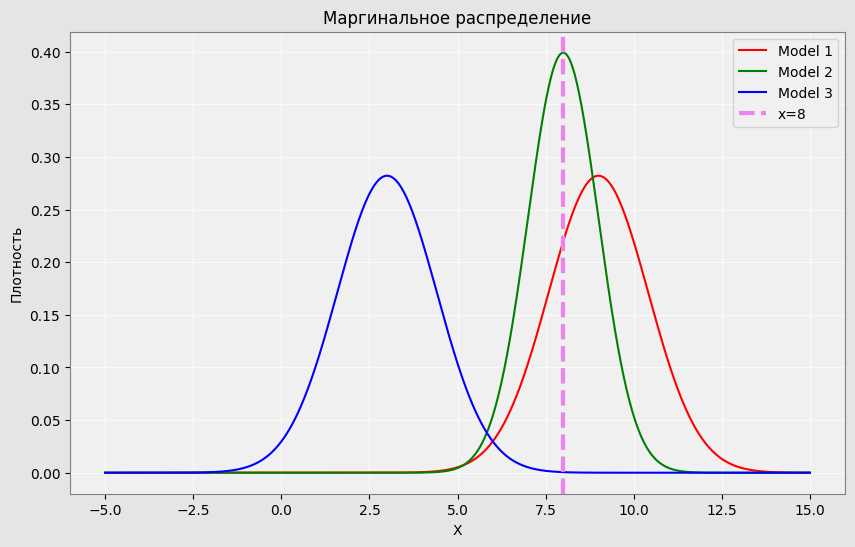

In [10]:
x_grid = np.linspace(-5, 15, 1000)
x_obs = 8

plt.figure(figsize=(10, 6))

for i, (ai, bi, ci, color) in enumerate(zip(a, b, c, colors)):
    mu_x = bi * ai + ci
    sigma_x = np.sqrt(1 + bi**2)

    density = sps.norm.pdf(x_grid, loc=mu_x, scale=sigma_x)
    plt.plot(x_grid, density, color=color, label=f'Model {i+1}')

plt.axvline(x_obs, color="violet", linestyle="--", linewidth=3, label=f"x={x_obs}")
plt.xlabel("X")
plt.ylabel("Плотность")
plt.title("Маргинальное распределение")
plt.grid(True)
plt.legend()
plt.show()

In [11]:
log_evidence = []
for ai, bi, ci in zip(a, b, c):
    mu = bi * ai + ci
    sigma = np.sqrt(1 + bi**2)
    log_ev = sps.norm.logpdf(x_obs, loc=mu, scale=sigma)
    log_evidence.append(log_ev)

log_evidence = np.array(log_evidence)

evidence = np.exp(log_evidence)

for i, (ev, log_ev) in enumerate(zip(evidence, log_evidence)):
    print(f"Model {i+1}: evidence={ev:.4f}")

Model 1: evidence=0.2197
Model 2: evidence=0.3989
Model 3: evidence=0.0005


Сделайте вывод.

Вывод:

В данной задаче мы вспомнили, как формируется апостериорное распределение, и на при помощи эксперимента показали, что при его помощи мы можем лучше определять истинное распределение $\theta$

__________________
### Задача 2.

Загрузите <a href="http://www.statsmodels.org/stable/datasets/generated/fair.html">данные</a> о внебрачных отношениях.
    
Оставьте только тех людей, которые изменяли, то есть величина `affairs` больше нуля. Бинаризуйте данные следующим образом:
* Долю времени во внебрачных отношения `affairs` по медиане всех значений;
* Уровень `rate_marriage` по значению 3.5;
* Возраст `age` по значению 30;
* Количество лет в браке `yrs_married` по значению 5.

Каждый из этих признаков описывается бернуллиевским распределением. Рассмотрим следующие модели на этих признаках:
* Все переменные независимы.
* `affairs` и `rate_marriage` зависимы, остальных зависимостей нет.
* `affairs` и `age` зависимы, остальных зависимостей нет.
* `affairs`,  `age` и  `yrs_married` зависимы, остальных зависимостей нет.
* несколько других на ваше усмотрение.

Выберите модель методом максимальной обоснованности.

*Указания.* 
1. Можно вывести одну формулу на все случаи, используя сопряженное распределение. Для начала стоит понять, какими распределениями описываются данные.
2. При реализации логарифмов обратите внимание на <a href="https://docs.scipy.org/doc/scipy/reference/special.html#gamma-and-related-functions">готовые специальные функции</a>. 

In [12]:
data = sm.datasets.fair.load_pandas()
df = data.data.copy()
df = df[df["affairs"] > 0]
df.head()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


In [13]:
affairs_median = df["affairs"].median()
df.loc[:, "affairs"] = (df["affairs"] > affairs_median).astype(int)
df.loc[:, "rate_marriage"] = (df["rate_marriage"] > 3.5).astype(int)
df.loc[:, "age"] = (df["age"] > 30).astype(int)
df.loc[:, "yrs_married"] = (df["yrs_married"] > 5).astype(int)

df.head()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,0.0,1.0,1.0,3.0,3.0,17.0,2.0,5.0,0.0
1,0.0,0.0,1.0,3.0,1.0,14.0,3.0,4.0,1.0
2,1.0,0.0,0.0,0.0,1.0,16.0,3.0,5.0,1.0
3,1.0,1.0,1.0,4.0,3.0,16.0,5.0,5.0,0.0
4,1.0,0.0,1.0,1.0,1.0,14.0,3.0,4.0,1.0


В случае если все переменные независимы, то гиперпараметры модели можно отбирать отдельно.

Пусть $a_1 \sim Bern(p_1)$. 

Сопряженным к бернуллевскому распределению является Бета распрделение, т.е. $p_1 \sim Beta(\alpha, \beta)$

Пусть имеем последовательность $x_1,..., x_N$.

Тогда обоснованность имеет вид:

$$
p_{\alpha, \beta}(x) = \int \frac{t^{\sum{x_i} + \alpha -1} \cdot (1 - t)^{N - \sum{x_i} + \beta - 1}}{B(\alpha, \beta)} dt = \frac{B(\alpha + \sum{x_i}, \beta + N - \sum{x_i})}{B(\alpha, \beta)}
$$


Разберем случай, когда две переменные зависимы, случай большего числа зависимых переменных получается аналогично.

Две зависимые переменные можно описать мультиномиальным распределением $Mult(p_{00}, p_{01}, p_{10}, p_{11})$, где в качестве индекса указаны пары.

Сопряженным к нему является распределение Дирихле: $Dir(\alpha_{00}, \alpha_{01}, \alpha_{10}, \alpha_{11})$. И апостериорное распределение имеет вид:
$$
Dir(\alpha_{00} + n_{00}, \alpha_{01} + n_{01}, \alpha_{10} + n_{10}, \alpha_{11} + n_{11})
$$

Запишем обоснованность:
$$
\begin{aligned}
p_{\boldsymbol{\alpha}}(\mathbf{n}) &= \int
\frac{N!}{\prod_{i,j} n_{ij}!} \prod_{i,j} p_{ij}^{\,n_{ij}} 
\cdot 
\frac{1}{B(\boldsymbol{\alpha})} \prod_{i,j} p_{ij}^{\alpha_{ij}-1} 
\, d\mathbf{p} \\

&= \frac{N!}{\prod_{i,j} n_{ij}!} \frac{1}{B(\boldsymbol{\alpha})} \int_{\sum p_{ij}=1} \prod_{i,j} p_{ij}^{\alpha_{ij}+n_{ij}-1} \, d\mathbf{p} \\

&= \frac{N!}{\prod_{i,j} n_{ij}!} \frac{1}{B(\boldsymbol{\alpha})} \cdot B(\alpha_{00}+n_{00},\dots,\alpha_{11}+n_{11}) \\

&= \frac{N!}{\prod_{i,j} n_{ij}!} \cdot 
\frac{\Gamma(\sum_{i,j} \alpha_{ij})}{\prod_{i,j} \Gamma(\alpha_{ij})} \cdot 
\frac{\prod_{i,j} \Gamma(\alpha_{ij}+n_{ij})}{\Gamma(\sum_{i,j} (\alpha_{ij}+n_{ij}))} \\

&= \frac{\Gamma(\sum_{i,j} \alpha_{ij})}{\prod_{i,j} \Gamma(\alpha_{ij})} \cdot 
\frac{\prod_{i,j} \Gamma(\alpha_{ij}+n_{ij})}{\Gamma(\sum_{i,j} \alpha_{ij} + N)}
\end{aligned}
$$


Подберем параметры путем методом максимизации обоснованности.

Для этого распишем функции для зависимых и независимых переменных.

In [14]:
def fit_beta_block(x, max_alpha=100):
    N = len(x); s = x.sum()
    def log_ev_ab(ab):
        a, b = ab
        if a <= 0 or b <= 0:
            return -np.inf
        return sp.betaln(a + s, b + N - s) - sp.betaln(a, b)
    res = minimize(lambda ab: -log_ev_ab(ab), x0=np.array([1.0,1.0]),
                   method="L-BFGS-B", bounds=[(1e-3, max_alpha)]*2)
    a, b = res.x
    log_ev = log_ev_ab(res.x)
    a_i, b_i = int(round(a)), int(round(b))
    log_ev_i = int(round(log_ev))
    return {
        "params": np.array([a_i, b_i]),
        "log_ev": log_ev_i,
        "dist": f"Beta({a_i},{b_i})"
    }


def fit_dirichlet_block(df, names, max_alpha=100):
    grid = pd.DataFrame(list(itertools.product([0,1], repeat=len(names))), columns=names)
    merged = df[names].merge(grid, how="right", on=names)
    counts = merged.value_counts(subset=names, sort=False).values.astype(float)
    N = counts.sum()
    def log_ev_alpha(alpha):
        alpha = np.asarray(alpha)
        if np.any(alpha <= 0):
            return -np.inf
        term1 = sp.gammaln(alpha.sum())
        term2 = -np.sum(sp.gammaln(alpha))
        term3 = np.sum(sp.gammaln(alpha + counts))
        term4 = -sp.gammaln(alpha.sum() + N)
        return term1 + term2 + term3 + term4
    res = minimize(lambda x: -log_ev_alpha(x), x0=np.ones(len(counts)),
                   method="L-BFGS-B", bounds=[(1e-3, max_alpha)]*len(counts))
    alpha_opt = res.x
    log_ev = log_ev_alpha(alpha_opt)
    alpha_int = [int(round(p)) for p in alpha_opt]
    log_ev_i = int(round(log_ev))
    return {
        "params": np.array(alpha_int),
        "log_ev": log_ev_i,
        "dist": "Dirichlet(" + ", ".join(map(str, alpha_int)) + ")"
    }


def evaluate_model(df, independent_blocks, dependent_blocks):
    results = {}
    total_log_ev = 0
    for name in independent_blocks:
        res = fit_beta_block(df[name].values)
        results[name] = res
        total_log_ev += res["log_ev"]
    for block in dependent_blocks:
        if len(block) == 1:
            res = fit_beta_block(df[block[0]].values)
            results[block[0]] = res
            total_log_ev += res["log_ev"]
        else:
            res = fit_dirichlet_block(df, block)
            results["_".join(block)] = res
            total_log_ev += res["log_ev"]
    return {"per_block": results, "total_log_ev": total_log_ev}


In [15]:
models = [
    {"ind": ["age","yrs_married","rate_marriage","affairs"], "dep": []},   # все независимы
    {"ind": ["age","yrs_married"], "dep": [["affairs","rate_marriage"]]},  # affairs & rate зависимы
    {"ind": ["yrs_married","rate_marriage"], "dep": [["affairs","age"]]},  # affairs & age зависимы
    {"ind": ["rate_marriage"], "dep": [["affairs","age","yrs_married"]]},  # `affairs`,  `age` и  `yrs_married` зависимы, остальных зависимостей нет.
    {"ind": ["age"], "dep": [["affairs","rate_marriage","yrs_married"]]},  # зависимы `affairs`, `rate_marriage` и `yrs_married`
    {"ind": [], "dep": [["age","yrs_married","rate_marriage","affairs"]]}  # все зависимы
]

In [16]:
pd.set_option("display.max_colwidth", None)
rows = []
for m in models:
    out = evaluate_model(df, m["ind"], m["dep"])
    row = {
        "model": str(m),
        "total_log_ev": out["total_log_ev"]
    }
    for k,v in out["per_block"].items():
        row[k] = v["dist"]
    rows.append(row)

df_models = pd.DataFrame(rows).sort_values("total_log_ev", ascending=False).reset_index(drop=True)
display(df_models)

,model,total_log_ev,age,yrs_married,rate_marriage,affairs,affairs_rate_marriage,affairs_age,affairs_age_yrs_married,affairs_rate_marriage_yrs_married,age_yrs_married_rate_marriage_affairs
0,"{'ind': ['rate_marriage'], 'dep': [['affairs', 'age', 'yrs_married']]}",-4772,NaN,NaN,"Beta(100,70)",NaN,NaN,NaN,"Dirichlet(10, 32, 1, 100, 53, 55, 2, 36)",NaN,NaN
1,"{'ind': [], 'dep': [['age', 'yrs_married', 'rate_marriage', 'affairs']]}",-4778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Dirichlet(6, 37, 12, 55, 20, 42, 35, 55, 1, 2, 1, 2, 73, 30, 100, 33)"
2,"{'ind': ['yrs_married', 'rate_marriage'], 'dep': [['affairs', 'age']]}",-5105,NaN,"Beta(100,29)","Beta(100,70)",NaN,NaN,"Dirichlet(39, 98, 100, 36)",NaN,NaN,NaN
3,"{'ind': ['age'], 'dep': [['affairs', 'rate_marriage', 'yrs_married']]}",-5178,"Beta(93,95)",NaN,NaN,NaN,NaN,NaN,NaN,"Dirichlet(5, 68, 9, 100, 28, 52, 42, 64)",NaN
4,"{'ind': ['age', 'yrs_married'], 'dep': [['affairs', 'rate_marriage']]}",-5325,"Beta(93,95)","Beta(100,29)",NaN,NaN,"Dirichlet(65, 100, 72, 95)",NaN,NaN,NaN,NaN
5,"{'ind': ['age', 'yrs_married', 'rate_marriage', 'affairs'], 'dep': []}",-5326,"Beta(93,95)","Beta(100,29)","Beta(100,70)","Beta(100,100)",NaN,NaN,NaN,NaN,NaN


**Выводы:**


В задаче мы получили аналитическое выражения для обоснованности в случае бернуллевского и мультиномиального распределения.

Воспользовавшись методом максимизации обоснованности мы определили оптимальные гиперпараметры для сопряженных распределений параметров моделей.


Сравнивая логарифмы обоснованностей видим, лучшей оказалась модель в которой оценка брака считается назависимой переменной, а остальные переменные зависимы.

__________________
### Задача 3.

Будем работать с датасетом __"bikes_rent.csv"__, в котором по дням записаны календарная информация и погодные условия, характеризующие автоматизированные пункты проката велосипедов, а также число прокатов в этот день. Последнее мы будем предсказывать; таким образом, мы будем решать задачу регрессии.

Данные предоставлены компанией capital bikeshare.

Для каждого дня проката известны следующие признаки (как они были указаны в источнике данных):
* `_season_`: 1 &mdash; весна, 2 &mdash; лето, 3 &mdash; осень, 4 &mdash; зима;
* `_yr_`: 0 &mdash; 2011, 1 &mdash; 2012;
* `_mnth_`: от 1 до 12;
* `_holiday_`: 0 &mdash; нет праздника, 1 &mdash; есть праздник;
* `_weekday_`: от 0 до 6;
* `_workingday_`: 0 &mdash; нерабочий день, 1 &mdash; рабочий день;
* `_weathersit_`: оценка благоприятности погоды от 1 (чистый, ясный день) до 4 (ливень, туман);
* `_temp_`: температура в Цельсиях;
* `_atemp_`: температура по ощущениям в Цельсиях;
* `_hum_`: влажность;
* `_windspeed(mph)_`: скорость ветра в милях в час;
* `_windspeed(ms)_`: скорость ветра в метрах в секунду;
* `_cnt_`: количество арендованных велосипедов &mdash; целевой признак.

Перед началом выполнения задачи проанализируйте данные, внимательно посмотрев на признаки и удалив явные выбросы.

In [17]:
df = pd.read_csv("/home/alexander/DS/BS_in_DA/hw1/bikes_rent.csv")
df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed(mph),windspeed(ms),cnt
0,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,4.805490,985
1,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,7.443949,801
2,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,7.437060,1349
3,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,4.800998,1562
4,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,5.597810,1600


In [18]:
df["cnt"] = np.log(df['cnt'])

Посмотрим на боксплоты для численных значений.

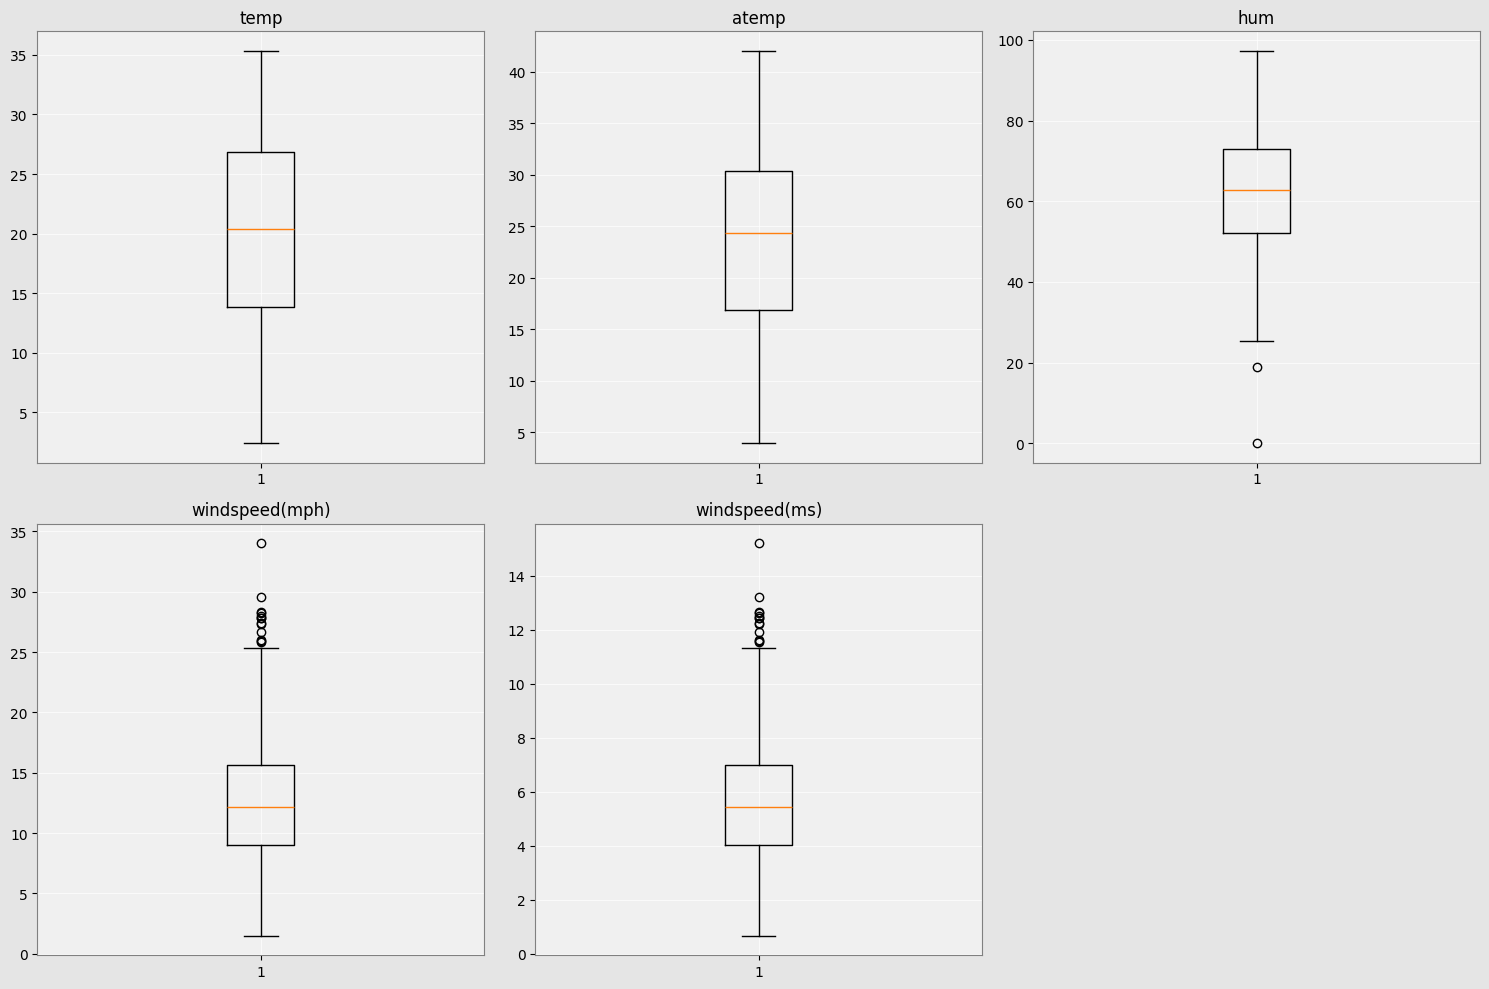

In [19]:
numerical_cols = ["temp", "atemp", "hum", "windspeed(mph)", "windspeed(ms)"]
categorical_cols = ["season", "yr", "mnth", "holiday", "weekday", "workingday", "weathersit"]


n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col)
    axes[i].grid(True)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Уберем выбросы по ветру и влажности.

In [20]:
df = df[(df["windspeed(ms)"] < 12) & (df["hum"] > 20)]

Также очевидно у нас есть сильно скоррелированные столбцы (например температура и ощущаемая температура)

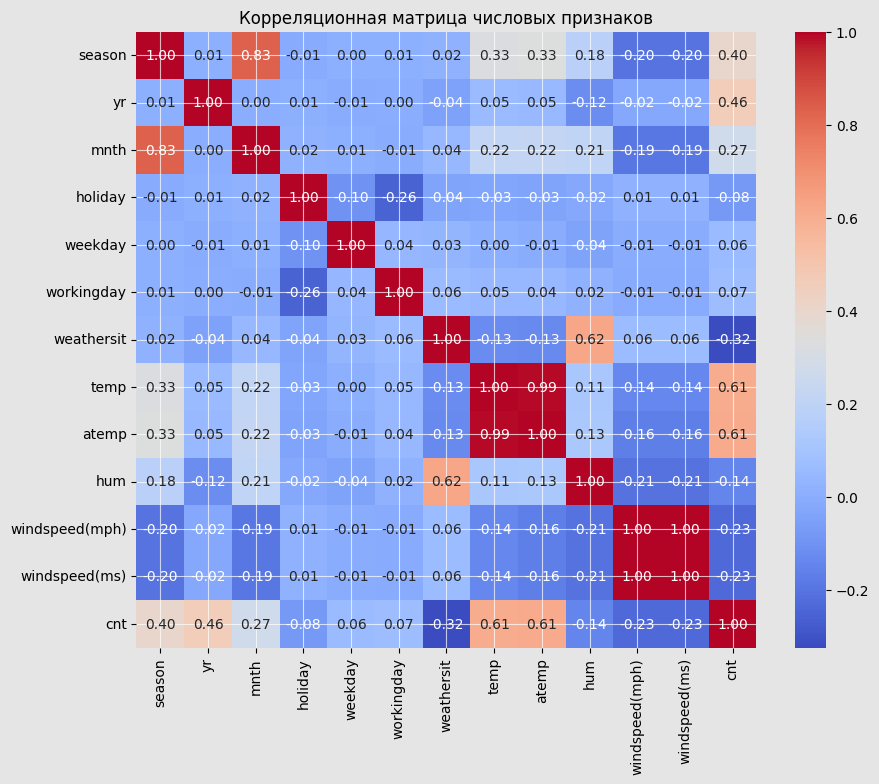

In [21]:
# numerical_cols = df.select_dtypes(include="number").columns
corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Корреляционная матрица числовых признаков")
plt.show()

In [22]:
optimal_df = df.drop(columns=["windspeed(mph)", "temp", "mnth"])

In [23]:
numerical_cols = ["atemp", "hum", "windspeed(ms)"]
categorical_cols = ["season", "yr", "holiday", "weekday", "workingday", "weathersit"]

Разделите данные на обучающую и тестовую части. Удаление выбросов из данных до разделения на трейн и тест необходимо для того, чтобы наши метрики на тесте не искажались из-за выбросов.

In [24]:
train_df, test_df = train_test_split(df[[*numerical_cols, *categorical_cols, "cnt"]], test_size=0.2, random_state=42)

In [25]:
train_df.shape, test_df.shape

((576, 10), (145, 10))

In [26]:
X_train, y_train = train_df.drop("cnt", axis=1), train_df["cnt"]
X_test, y_test = test_df.drop("cnt", axis=1), test_df["cnt"]

Сделайте на обучающей части все необходимые преобразования данных.

Мы уже избавились от выбросов и скоррелирванных столбцов. Для дальнейшей работы осталось закодировать категориальные данные и нормализовать числовые параметры.

In [27]:
scaler = MinMaxScaler()
X_train_num = pd.DataFrame(
    scaler.fit_transform(X_train[numerical_cols]),
    columns=numerical_cols,
    index=X_train.index
)
X_test_num = pd.DataFrame(
    scaler.transform(X_test[numerical_cols]),
    columns=numerical_cols,
    index=X_test.index
)

X_train_cat = pd.DataFrame(index=X_train.index)
X_test_cat = pd.DataFrame(index=X_test.index)

for col in categorical_cols:
    tmp = pd.DataFrame({col: X_train[col], 'target': y_train})
    mean_map = tmp.groupby(col)['target'].mean()
    
    X_train_cat[col + "_mean"] = X_train[col].map(mean_map)
    X_test_cat[col + "_mean"] = X_test[col].map(mean_map)
    
    X_test_cat[col + "_mean"] = X_test_cat[col + "_mean"].fillna(y_train.mean())

X_train_df = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_df = pd.concat([X_test_num, X_test_cat], axis=1)

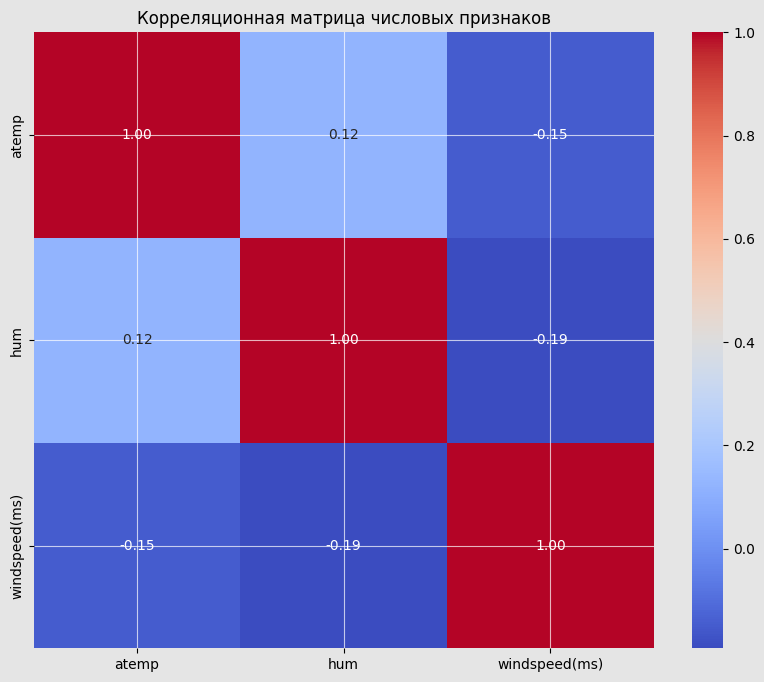

In [28]:
corr_matrix = X_train_df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Корреляционная матрица числовых признаков")
plt.show()

In [29]:
def get_metrics(y_true, y_pred, model_name="Linear Regression"):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    
    nonzero_idx = y_true != 0
    if np.any(nonzero_idx):
        mape = np.mean(np.abs((y_true[nonzero_idx] - y_pred[nonzero_idx]) / y_true[nonzero_idx])) * 100
    else:
        mape = np.nan
    
    metrics = {
        "Metric": ["MSE", "MAE", "MAPE (%)"],
        model_name: [np.round(mse, 2), np.round(mae, 2), np.round(mape, 2)]
    }
    
    return pd.DataFrame(metrics)

def plot_test_pred(y_true, y_pred, model_name="Model"):
    plt.figure(figsize=(8,6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             'r--', lw=2)  # линия y = x
    plt.xlabel("Истинные значения")
    plt.ylabel("Предсказанные значения")
    plt.title(f"Предсказания vs Истинные значения ({model_name})")
    plt.grid(True)
    plt.show()


In [30]:
X_train_df.head()

,atemp,hum,windspeed(ms),season_mean,yr_mean,holiday_mean,weekday_mean,workingday_mean,weathersit_mean
459,0.626003,0.278110,0.422195,8.467870,8.572481,8.318158,8.314755,8.355564,8.409838
361,0.276788,0.327387,0.722997,7.697116,8.032859,8.318158,8.314755,8.355564,8.409838
385,0.131992,0.797249,0.533125,7.697116,8.572481,8.318158,8.250573,8.217875,8.192179
148,0.739113,0.779306,0.509952,8.467870,8.032859,8.318158,8.216892,8.217875,8.409838
215,0.806949,0.691388,0.465257,8.617588,8.032859,8.318158,8.348216,8.355564,8.192179


Постройте по обучающей части следующие модели:
1. Обычная линейная регрессия. Возможно, для её обучения потребуется что-то сделать с данными.
2. Ридж-регрессия, при этом выполните следующие действия.
     * Выпишите формулу обоснованности модели (по аналогии с тем, что делали на занятии).
     * Проведите отбор признаков по принципу максимальной обоснованности. Можно использовать различные стратегии отбора признаков.
3. ARD-регрессия (метод релевантных векторов). Можно использовать <a href="https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ARDRegression.html">реализацию</a>.

Сравните обоснованность моделей из пунктов 2-3. Также, в каждом пункте визуализируйте значения коэффициентов с помощью `plt.bar`. Какой набор значимых признаков выделяет ARD-регрессия?

1. Линейная регрессия

Раннее мы уже сделали все необходимые преобразования данных, так что для линейной регрессии в них нет необходимости.

In [49]:
model = LinearRegression()
model.fit(X_train_df.values, y_train)

preds = model.predict(X_test_df.values)
lr_df = get_metrics(np.exp(y_test), np.exp(preds))
lr_df

,Metric,Linear Regression
0,MSE,1146524.11
1,MAE,768.79
2,MAPE (%),89.91


In [36]:

def plot_model_coefs(model, X_df, model_name="Model"):
    coefs = model.coef_
    features = X_df.columns

    coef_sorted = np.argsort(np.abs(coefs))[::-1]

    plt.figure(figsize=(12,6))
    plt.bar([features[i] for i in coef_sorted], coefs[coef_sorted])
    plt.xticks(rotation=90)
    plt.xlabel("Признаки")
    plt.ylabel("Коэффициенты")
    plt.title(f"Коэффициенты модели: {model_name}")
    plt.grid(True, axis="y", linestyle="--", alpha=0.7)
    plt.show()

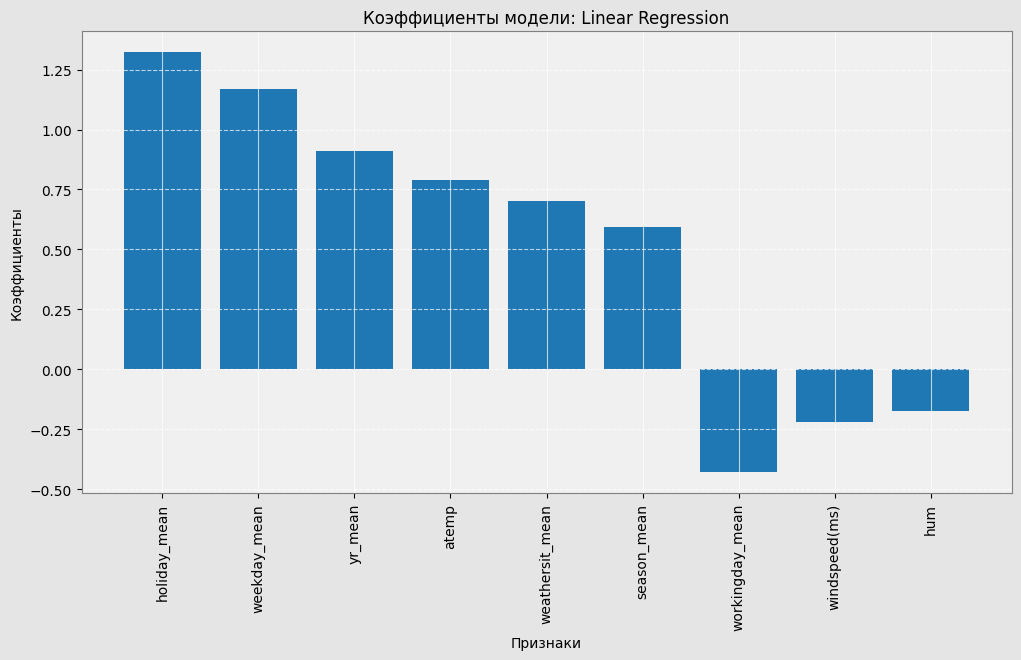

In [37]:
plot_model_coefs(model, X_train_df, "Linear Regression")

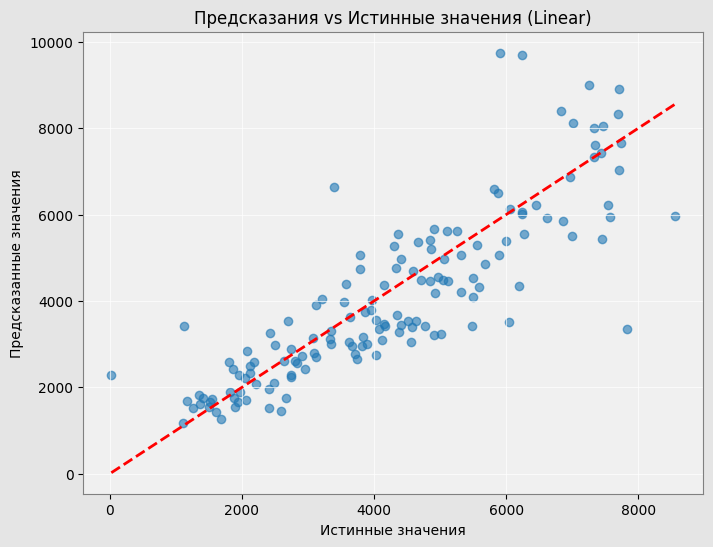

In [38]:
plot_test_pred(np.exp(y_test), np.exp(preds), "Linear")

2. Ridge регрессия.

Все нужные преобразования были нами сделаны при подготовке, так что осталось лишь отобрать признаки.

Для начала выпишем формулу обоснованности, полученную на семинаре. Для удобства будем вычислять логарифм обоснованности:

Итак пусть у нас имеется модель: $y(x) = x^T\theta$

Данные: $Y=x\theta + \epsilon$, где $Y|\theta \sim \mathcal{N}(x\theta, \beta^{-1}I)$, $\beta \in \mathbb{R}$

В качестве априорного распределения берем $\theta \sim \mathcal{N}(0, A^{-1})$, $A \in \mathbb{R^{d \times d}}$

Апостериорное распределение имеет вид: $\theta|Y \sim \mathcal{N}(t_0, B^{-1})$, где $B = \beta X^TX + A, t_0 = \beta B^{-1}X^TY$

И в случае, если $A = \lambda I$, получаем следующее представление логарифма обоснованности

$$
log p_{A, B}(Y) = \frac{n}{2}log(2\pi) + \frac{1}{2}log(detA) + \frac{n}{2}log(\beta) - \frac{1}{2}log(detB) - \frac{1}{2}(\beta ||Y - Xt_0||^2 + t_0^TAt_0)$$

Воспользуемся уже готовой реализацией байесовского регрессора из библиотеки sklearn.

Жадно отберем признаки, которые увеличивают обоснованность.

In [39]:
def greedy_backward_selection(X, y, verbose=True):
    remaining = list(X.columns)
    history = []

    model = BayesianRidge(compute_score=True)
    model.fit(X[remaining], y)
    best_score = model.scores_[-1]
    history.append((list(remaining), best_score))
    
    if verbose:
        print(f"Start: {len(remaining)} features, log-evidence = {best_score:.3f}")

    improved = True
    while improved and len(remaining) > 1:
        scores = []
        for col in remaining:
            candidate_features = [f for f in remaining if f != col]
            model = BayesianRidge(compute_score=True)
            model.fit(X[candidate_features], y)
            score = model.scores_[-1]
            scores.append((col, score))
        
        scores = sorted(scores, key=lambda x: x[1], reverse=True)
        best_feature, best_new_score = scores[0]

        if best_new_score > best_score:
            remaining.remove(best_feature)
            best_score = best_new_score
            history.append((list(remaining), best_score))
            if verbose:
                print(f"Removed {best_feature}, new log-evidence = {best_score:.3f}")
        else:
            improved = False

    return remaining, history

In [40]:
selected_features, history = greedy_backward_selection(X_train_df, y_train)

print("\nВыбранные признаки:")
print(selected_features)

print("\nИстория:")
for feats, score in history:
    print(f"{len(feats)} features, log-evidence = {score:.3f}")

Start: 9 features, log-evidence = -73.556
Removed workingday_mean, new log-evidence = -72.941

Выбранные признаки:
['atemp', 'hum', 'windspeed(ms)', 'season_mean', 'yr_mean', 'holiday_mean', 'weekday_mean', 'weathersit_mean']

История:
9 features, log-evidence = -73.556
8 features, log-evidence = -72.941


Теперь обучим модель

In [41]:
param_grid = {
    "alpha_1": [1e-1,1e0, 1e1],
    "alpha_2": [1e-8, 1e-3, 1e-1, 1e0],
    "lambda_1": [1e-8, 1e-3, 1e-1],
    "lambda_2": [1e-1, 1e0, 1e1],
}

model = BayesianRidge()

grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train_df[selected_features], y_train)

print("Лучшие параметры:", grid.best_params_)
print("Лучший скор (CV RMSE):", (-grid.best_score_)**0.5)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_df[selected_features])
rr_df = get_metrics(np.exp(y_test), np.exp(y_pred), "Bayesian Ridge")
rr_df

Лучшие параметры: {'alpha_1': 0.1, 'alpha_2': 1.0, 'lambda_1': 0.1, 'lambda_2': 1.0}
Лучший скор (CV RMSE): 0.27031867251359054


,Metric,Bayesian Ridge
0,MSE,1139901.19
1,MAE,770.85
2,MAPE (%),89.49


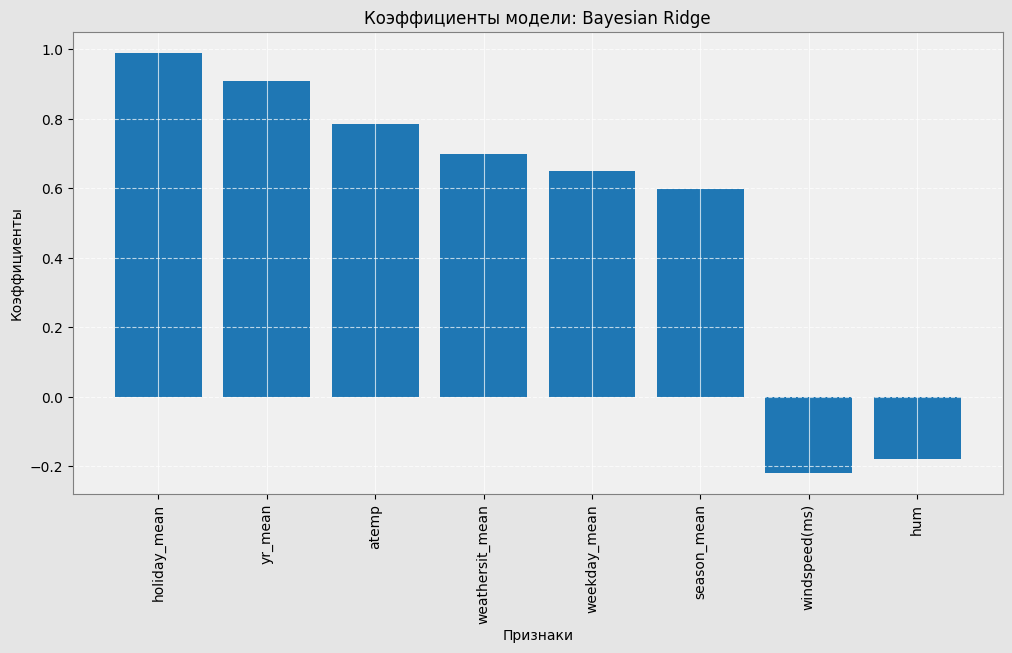

In [42]:
plot_model_coefs(best_model, X_train_df[selected_features], "Bayesian Ridge")

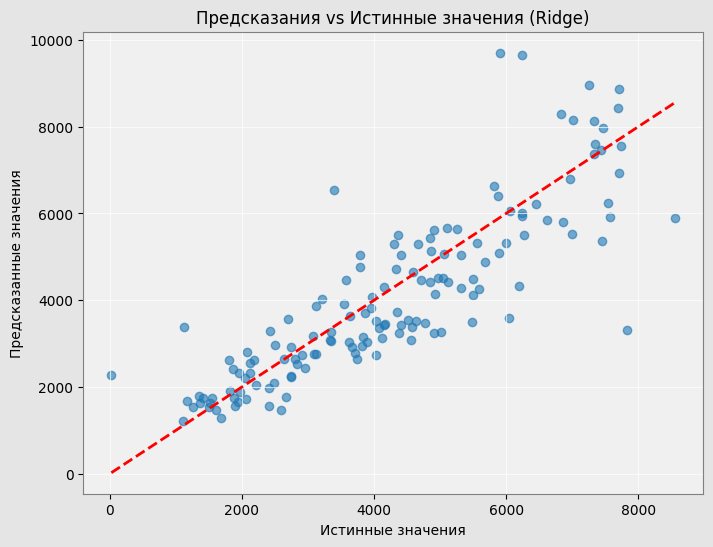

In [43]:
plot_test_pred(np.exp(y_test), np.exp(y_pred), "Ridge")

3. ARDReggresion


In [44]:
model = ARDRegression()

model.fit(X_train_df,y_train)
y_pred = model.predict(X_test_df)

ard_df = get_metrics(np.exp(y_test),np.exp(y_pred), "ARDRegression")

ard_df

,Metric,ARDRegression
0,MSE,1134941.11
1,MAE,769.56
2,MAPE (%),89.72


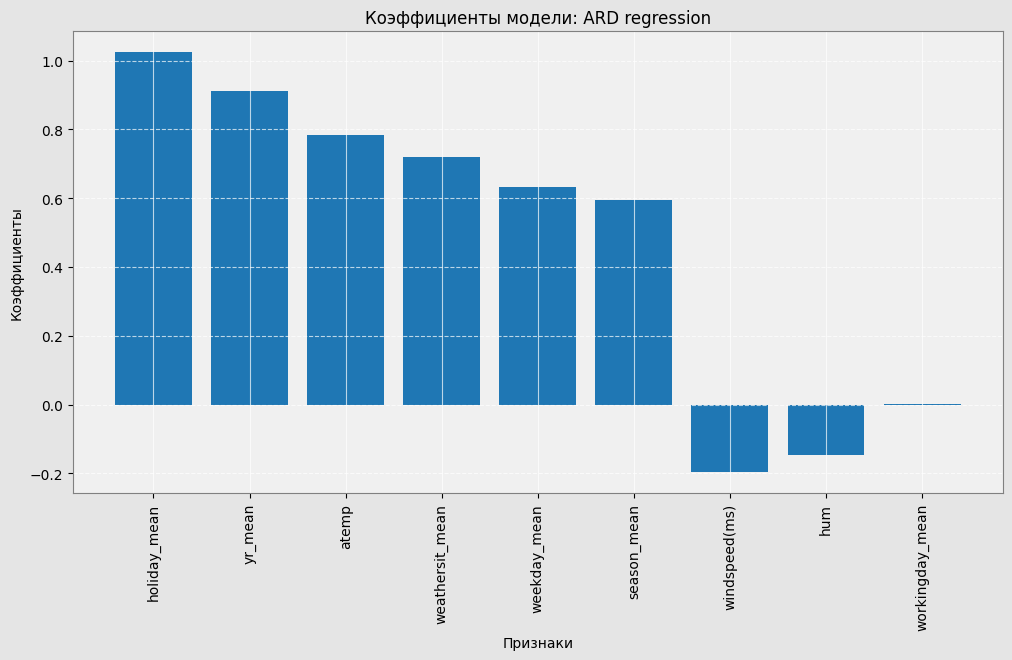

In [45]:
plot_model_coefs(model, X_train_df, "ARD regression")

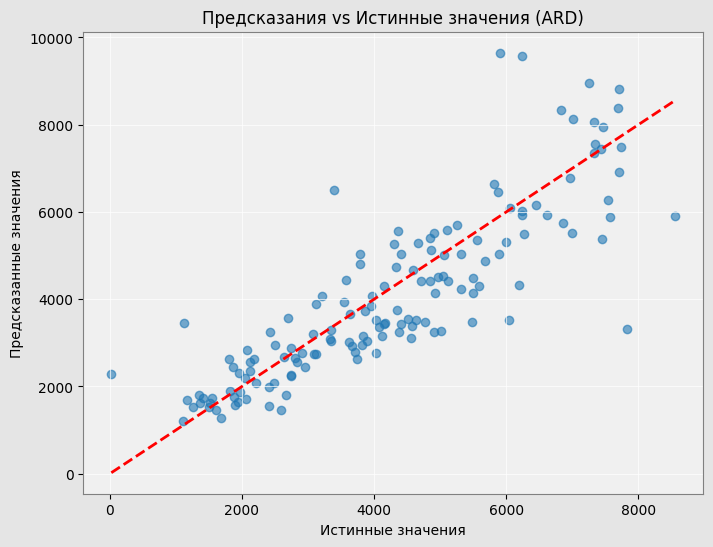

In [46]:
plot_test_pred(np.exp(y_test), np.exp(y_pred), "ARD")

Сравните качество моделей на тестовом множестве по метрикам MSE, MAE, MAPE.

In [47]:
lr_df["Metric"] = lr_df["Metric"].astype(str)
rr_df["Metric"] = rr_df["Metric"].astype(str)
ard_df["Metric"] = ard_df["Metric"].astype(str)

result_df = pd.merge(lr_df, rr_df, on="Metric", how="outer", suffixes=("_LR", "_RR"))
result_df = pd.merge(result_df, ard_df, on="Metric", how="outer")

result_df


,Metric,Linear Regression,Bayesian Ridge,ARDRegression
0,MAE,768.79,770.85,769.56
1,MAPE (%),89.91,89.49,89.72
2,MSE,1146524.11,1139901.19,1134941.11


**Вывод:**

В задаче мы при помощи максимизации обоснованности попробовали отобрать признаки, однако прироста качества увидеть не удалось.

Применение ARD также не дало прироста качества.


Результаты странные, впрочем как я заметил на графике, данные очень зашумлены, из за чего линейные модели справляются тут плохо (плохо справлялись и бустинги со случайными лесами)